# Tarea 2

Cálculo simbólico de las matrices $[K]$, autovalores y autovectores para sistemas de $3$, $4$ y $5$ masas.

Se usa `SymPy` para obtener resultados exactos y `display()` para que las expresiones se rendericen directamente en VS Code/Jupyter.


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

k = sp.symbols('k', positive=True)


## 1. Matriz del sistema

Para $n$ masas iguales, con resortes iguales $k$ y ambos extremos fijos,

$$
[K]_n =
k
\begin{bmatrix}
-2 & 1 & 0 & \cdots & 0 \\
1 & -2 & 1 & \ddots & \vdots \\
0 & 1 & -2 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & 1 \\
0 & \cdots & 0 & 1 & -2
\end{bmatrix}.
$$

In [2]:
def matriz_K(n):
    K = sp.zeros(n)

    for i in range(n):
        K[i, i] = -2 * k

        if i > 0:
            K[i, i - 1] = k

        if i < n - 1:
            K[i, i + 1] = k

    return K


## 2. Autovalores y autovectores

SymPy calcula directamente los autovalores y sus espacios propios.


In [3]:
def resultados_sistema(n):
    K = matriz_K(n)
    resultados = K.eigenvects()

    # Ordenar de lambda_1 a lambda_n, de mayor a menor.
    resultados.sort(key=lambda r: float(r[0].subs(k, 1)), reverse=True)

    return K, resultados


for n in (3, 4, 5):
    print(f"Sistema de {n} masas")
    print("-" * 40)

    K, resultados = resultados_sistema(n)

    display(K)

    for j, (lam, multiplicidad, vectores) in enumerate(resultados, start=1):
        print(f"Modo {j}")
        display(lam)
        display(vectores[0])

    print()


Sistema de 3 masas
----------------------------------------


Matrix([
[-2*k,    k,    0],
[   k, -2*k,    k],
[   0,    k, -2*k]])

Modo 1


k*(-2 + sqrt(2))

Matrix([
[      1],
[sqrt(2)],
[      1]])

...

-3*k

Matrix([
[-1],
[ 1],
[ 0],
[-1],
[ 1]])

Modo 5


k*(-2 - sqrt(3))

Matrix([
[       1],
[-sqrt(3)],
[       2],
[-sqrt(3)],
[       1]])

## 3. Gráfica de los autovectores

Para representar la forma espacial de cada modo se agregan los extremos fijos:

$$
u_0 = 0,
\qquad
u_{n+1}=0.
$$

Los autovectores se normalizan únicamente para facilitar la comparación visual.


Sistema de 3 masas


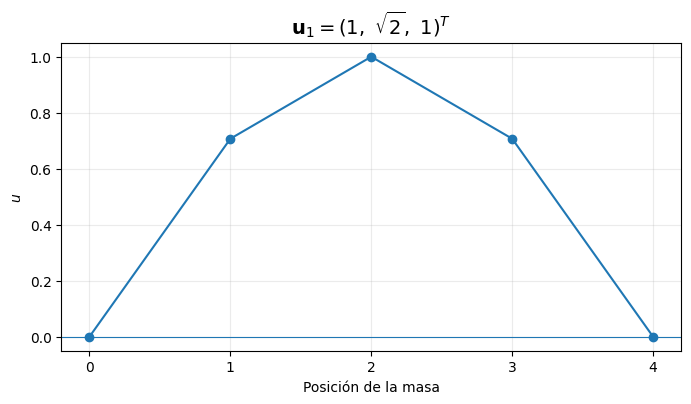

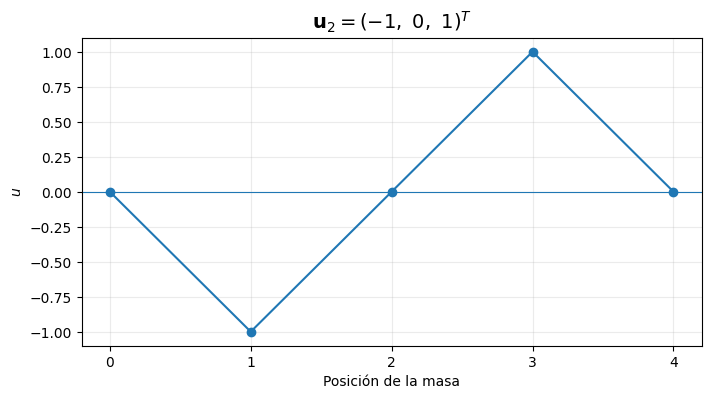

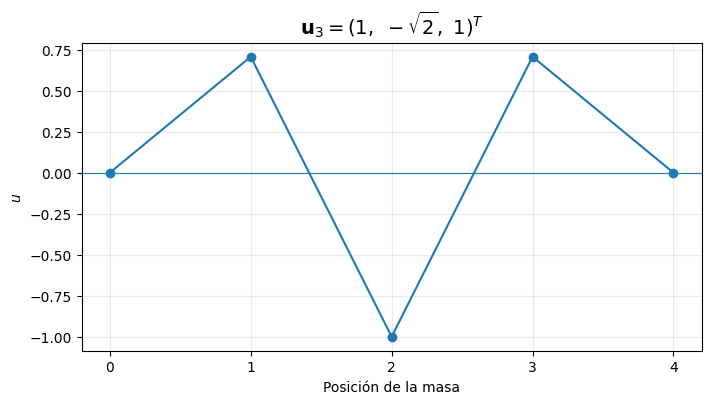

Sistema de 4 masas


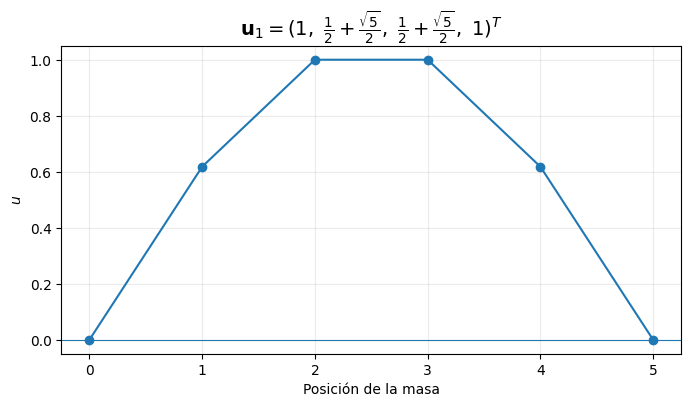

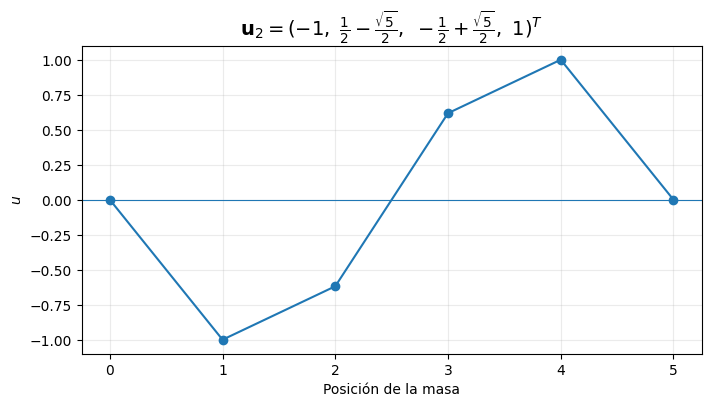

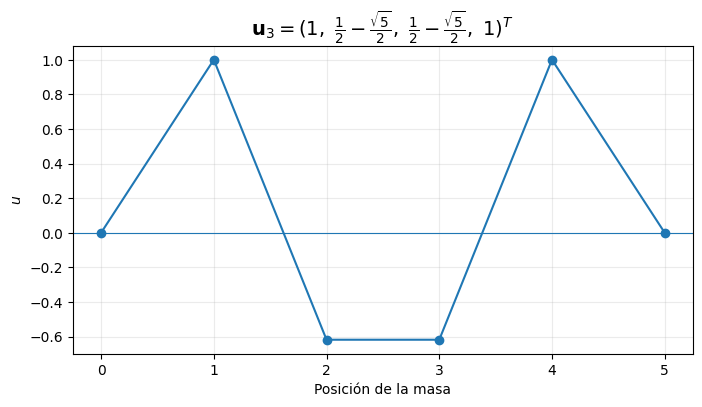

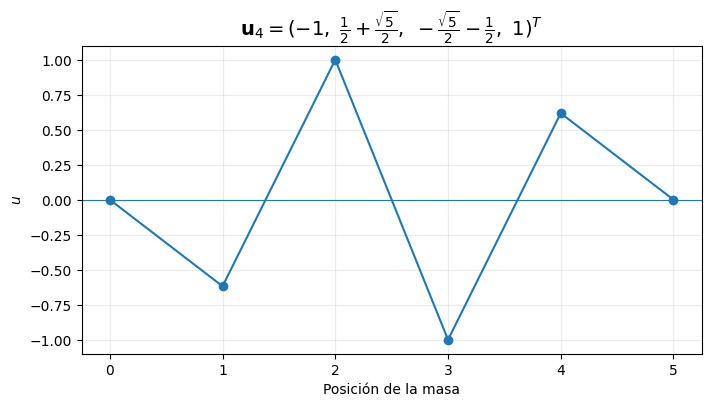

Sistema de 5 masas


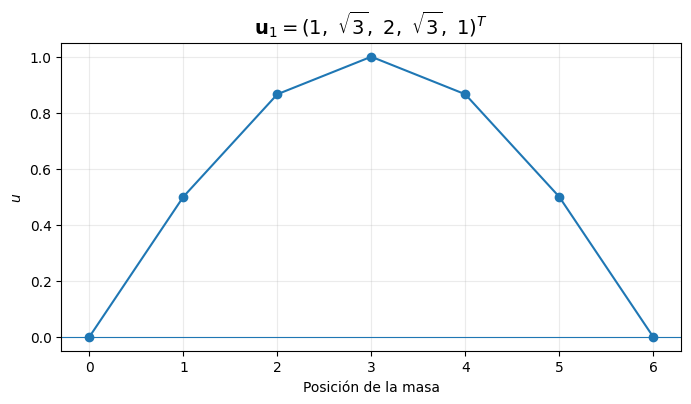

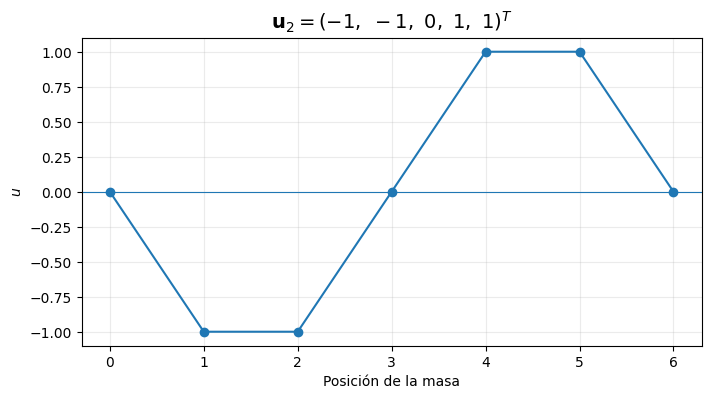

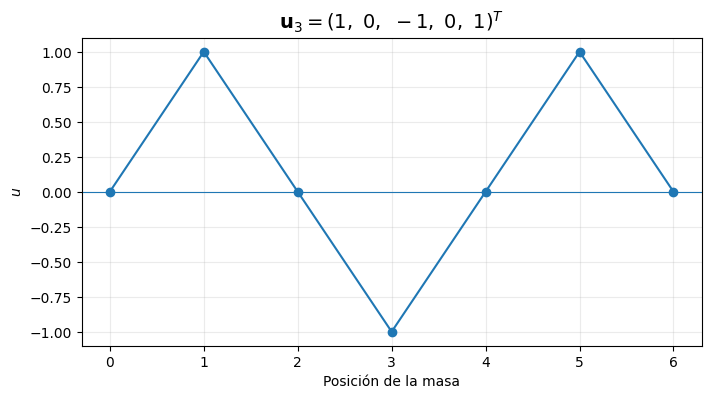

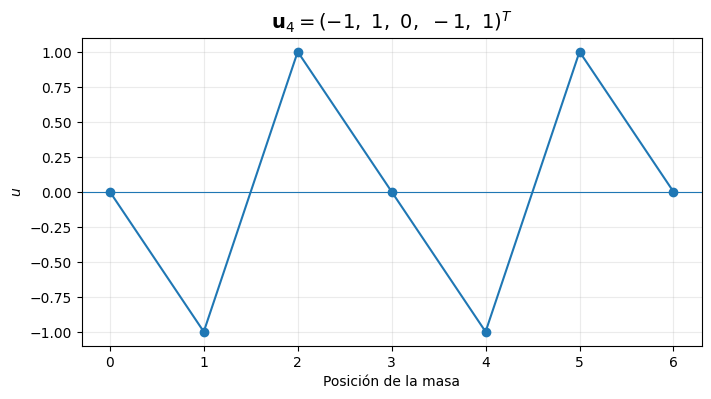

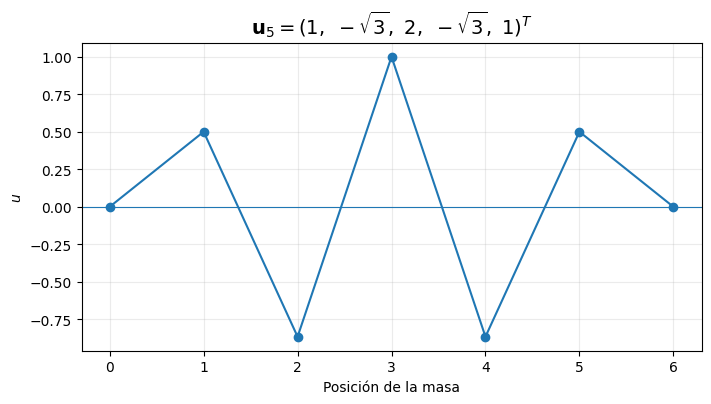

In [11]:
def graficar_autovectores(n):
    K, resultados = resultados_sistema(n)

    x = np.arange(n + 2)

    for j, (lam, multiplicidad, vectores) in enumerate(resultados, start=1):
        u_sym = sp.Matrix(vectores[0])

        # Vector numérico para graficar
        u = np.array(u_sym, dtype=float).flatten()

        # Normalización visual
        u = u / np.max(np.abs(u))

        y = np.concatenate(([0], u, [0]))

        # Autovector para el título
        componentes = r",\ ".join(
            sp.latex(valor) for valor in u_sym
        )

        vector_texto = rf"$\mathbf{{u}}_{j} = ({componentes})^T$"

        fig, ax = plt.subplots(figsize=(8, 4))

        ax.plot(x, y, marker="o")
        ax.axhline(0, linewidth=0.8)

        ax.set_title(vector_texto, fontsize=14)

        ax.set_xlabel("Posición de la masa")
        ax.set_ylabel(r"$u$")
        ax.set_xticks(x)
        ax.grid(alpha=0.25)

        plt.show()


for n in (3, 4, 5):
    print(f"Sistema de {n} masas")
    graficar_autovectores(n)

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


# -----------------------------
# Datos del sistema
# -----------------------------

k = 1
m = 1

# Autovalores
lambda_1 = (-3 + np.sqrt(5)) / 2 * k
lambda_2 = (-3 - np.sqrt(5)) / 2 * k

# Frecuencias naturales
omega_1 = np.sqrt(-lambda_1 / m)
omega_2 = np.sqrt(-lambda_2 / m)

# Autovectores
u1 = np.array([1, (1 + np.sqrt(5)) / 2])
u2 = np.array([1, (1 - np.sqrt(5)) / 2])

# Normalización para que quepan bien en la animación
u1 = u1 / np.max(np.abs(u1))
u2 = u2 / np.max(np.abs(u2))


# -----------------------------
# Función para dibujar resortes
# -----------------------------

def dibujar_resorte(ax, x0, x1, y=0, coils=8, amplitude=0.08):
    x = np.linspace(x0, x1, 100)

    # Línea central del resorte
    z = np.linspace(0, 1, 100)

    # Extremos rectos + zona de espiras
    y_spring = np.zeros_like(x)

    inicio = int(0.08 * len(x))
    fin = int(0.92 * len(x))

    y_spring[inicio:fin] = (
        amplitude
        * np.sin(
            np.linspace(0, coils * 2 * np.pi, fin - inicio)
        )
    )

    ax.plot(x, y + y_spring, linewidth=1.5)


# -----------------------------
# Crear figura
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Posiciones de equilibrio
x1_eq = 1.5
x2_eq = 3.0

# Amplitud física de la animación
A = 0.45


def dibujar_sistema(ax, desplazamientos, modo, tiempo):
    ax.clear()

    d1, d2 = desplazamientos

    x1 = x1_eq + A * d1
    x2 = x2_eq + A * d2

    # Pared izquierda
    ax.plot([0, 0], [-0.35, 0.35], linewidth=4)

    # Resorte pared -> m1
    dibujar_resorte(ax, 0.08, x1 - 0.18)

    # Resorte m1 -> m2
    dibujar_resorte(ax, x1 + 0.18, x2 - 0.18)

    # Masas
    ax.scatter(x1, 0, s=700, zorder=5)
    ax.scatter(x2, 0, s=700, zorder=5)

    # Etiquetas
    ax.text(x1, 0, r"$m_1$", ha="center", va="center", fontsize=12)
    ax.text(x2, 0, r"$m_2$", ha="center", va="center", fontsize=12)

    # Posiciones de equilibrio
    ax.plot(
        [x1_eq, x2_eq],
        [0, 0],
        "o",
        markersize=4,
        alpha=0.3
    )

    # Flechas de desplazamiento
    if abs(d1) > 1e-5:
        ax.annotate(
            "",
            xy=(x1, -0.25),
            xytext=(x1_eq, -0.25),
            arrowprops=dict(arrowstyle="->", linewidth=1.5)
        )

    if abs(d2) > 1e-5:
        ax.annotate(
            "",
            xy=(x2, -0.25),
            xytext=(x2_eq, -0.25),
            arrowprops=dict(arrowstyle="->", linewidth=1.5)
        )

    ax.set_xlim(-0.4, 4.0)
    ax.set_ylim(-0.5, 0.5)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(f"Modo {modo}")

    ax.set_aspect("equal")


# -----------------------------
# Animación
# -----------------------------

T = 2 * np.pi / omega_1
frames = 180


def actualizar(frame):

    t = frame / frames * T

    # Modo 1
    factor_1 = np.cos(omega_1 * t)
    desplazamiento_1 = factor_1 * u1

    # Modo 2
    factor_2 = np.cos(omega_2 * t)
    desplazamiento_2 = factor_2 * u2

    dibujar_sistema(
        axes[0],
        desplazamiento_1,
        1,
        t
    )

    dibujar_sistema(
        axes[1],
        desplazamiento_2,
        2,
        t
    )


anim = FuncAnimation(
    fig,
    actualizar,
    frames=frames,
    interval=30,
    repeat=True
)

plt.close(fig)




# HTML(anim.to_jshtml())

In [15]:
T = 2 * np.pi / omega_1
frames = 120

anim = FuncAnimation(
    fig,
    actualizar,
    frames=frames,
    interval=40,
    repeat=True
)

anim.save(
    "modos_vibracion.gif",
    writer="pillow",
    fps=25
)